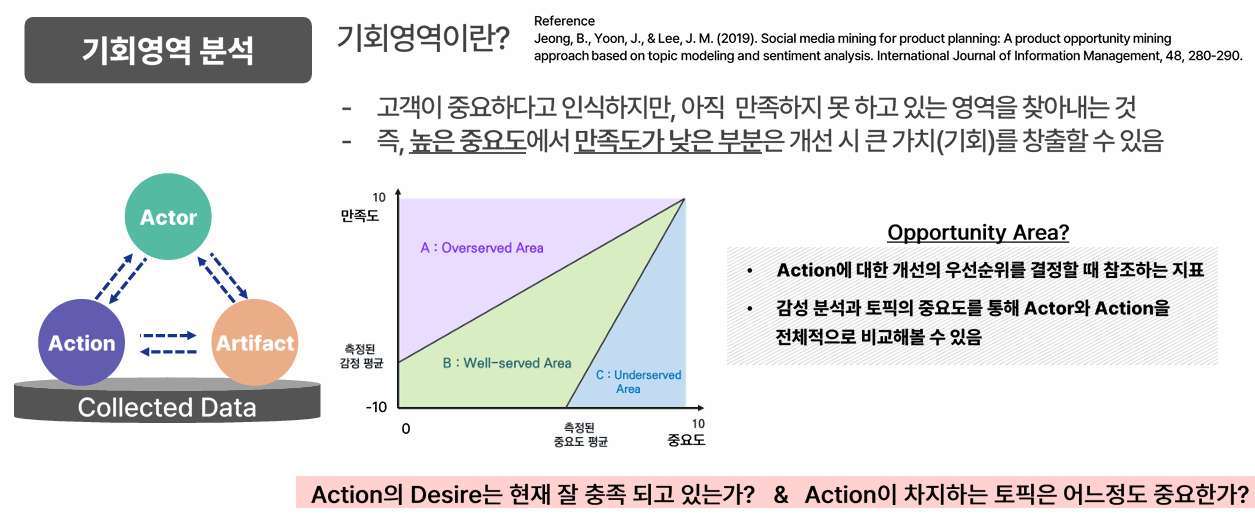

### 0.데이터로딩
- 분석을 수행할 actor들의 action을 모두 로딩

In [ ]:
# 분석 라이브러리 설치
!pip install new_value_analysis

In [ ]:
import pandas as pd

In [ ]:
# pickle 내용을 넣을 리스트
df_list = []

# 모든 actor의 action 데이터를 읽어서 리스트로 통합
for i in range(2) :
  df_list.append(pd.read_pickle(f"/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/cluster_df_{i}_action.pkl"))

In [ ]:
len(df_list)

2

In [ ]:
# 하나의 데이터로 병합
df = pd.concat(df_list, axis=0) # 행 방향으로 병합
df.reset_index(inplace=True) # 인덱스 리셋

In [ ]:
df.shape # 2개의 actor에 대한 action들의 병합데이터

(1334, 8)

### 1.satisfaction(만족도)
- 감성사전을 기반으로 만족도 점수계산 실시
- 프로젝트 진행시에는 인공지능기반 감성분석 모델을 활용해도 좋음

#### 1.1 감성사전 불러오기
- KNU 한국어 감성사전
- 군산대학교 소프트웨어융합공학과 랩실에서 제작한 자료
- 단어에 대한 감성 점수가 부여된 데이터
- 긍/부정적인 의미를 해석 할 수 있게 만든 단어사전

In [ ]:
import json

In [ ]:
# 감성사전 파일 읽기
# word : 원래 단어토큰 / word_root : 단어의 표준화된 형태 / polarity : 감성점수(음수->부정, 양수->긍정)
with open('/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/SentiWord_info.json', 'rb') as f :
  sent_dict = json.load(f)

In [ ]:
print(sent_dict)

[{'word': '(-;', 'word_root': '(', 'polarity': '1'}, {'word': '(;_;)', 'word_root': '(;_;)', 'polarity': '-1'}, {'word': '(^^)', 'word_root': '(^^)', 'polarity': '1'}, {'word': '(^-^)', 'word_root': '(^-^)', 'polarity': '1'}, {'word': '(^^*', 'word_root': '(', 'polarity': '1'}, {'word': '(^_^)', 'word_root': '(^_^)', 'polarity': '1'}, {'word': '(^_^;', 'word_root': '(', 'polarity': '-1'}, {'word': '(^o^)', 'word_root': '(^o^)', 'polarity': '1'}, {'word': '(-_-)', 'word_root': '(-_-)', 'polarity': '-1'}, {'word': '(T_T)', 'word_root': '(T_T)', 'polarity': '-1'}, {'word': '(ㅡㅡ)', 'word_root': '(', 'polarity': '-1'}, {'word': ')-:', 'word_root': ')', 'polarity': '-1'}, {'word': '*^^*', 'word_root': '*', 'polarity': '1'}, {'word': '/^o^\\', 'word_root': '/', 'polarity': '1'}, {'word': ':(', 'word_root': ':', 'polarity': '1'}, {'word': ":'-(", 'word_root': ':', 'polarity': '1'}, {'word': ':-(', 'word_root': ':', 'polarity': '1'}, {'word': ':)', 'word_root': ':', 'polarity': '-1'}, {'word': 

#### 1.2 리뷰토큰과 일치하는 감성단어 등록함수 정의
- 정교한 추출을 진행하려면 감성사전에 맞는 전처리 필요
- 현재 KNU 사전에는 바이그램 형태의 단어가 많아 전처리 진행시 바이그램을 수행할 필요가 있음

In [ ]:
def sentiment_score(sent_dict, review_token_list) : # 감성사전과 리뷰토큰을 파라미터로 입력
  # 하나의 문서에 대한 감성단어(점수)를 담을 리스트
  result_list = []

  for token in review_token_list : # 입력된 doc을 기준으로 반복처리
    for senti_info in sent_dict : # 입력된 감성사전을 기준으로 반복처리
      if token == senti_info['word'] : # 입력토큰과 감성사전단어가 일치하면
        result_list.append((senti_info['polarity'], senti_info['word'])) # 감성점수와 단어를 리스트에 추가

  return result_list # 결과 반환


In [ ]:
# 테스트 -> 나중에 감성점수를 합산해서 활용
sentiment_score(sent_dict, df.loc[0,"tagged_review"])

[('1', '아끼다'),
 ('1', '아끼다'),
 ('-1', '없다'),
 ('-2', '버리다'),
 ('-1', '벗어나다'),
 ('2', '좋다'),
 ('-2', '아니다'),
 ('-2', '비싸다'),
 ('-2', '후회'),
 ('-1', '없다'),
 ('-2', '아니다'),
 ('-1', '없다')]

#### 1.3 감성점수 구하기
- 감성사전에 맞는 전처리 필수
(품사필터링, n-gram, 어근추출 등)

In [ ]:
from tqdm import tqdm

In [ ]:
# doc별로 감성단어 추출결과를 담을 리스트
sentiment = []

for review in tqdm(df['tagged_review']) :
  sentiment.append(sentiment_score(sent_dict, review))

100%|██████████| 1334/1334 [03:57<00:00,  5.61it/s]


In [ ]:
sentiment[:5]

[[('1', '아끼다'),
  ('1', '아끼다'),
  ('-1', '없다'),
  ('-2', '버리다'),
  ('-1', '벗어나다'),
  ('2', '좋다'),
  ('-2', '아니다'),
  ('-2', '비싸다'),
  ('-2', '후회'),
  ('-1', '없다'),
  ('-2', '아니다'),
  ('-1', '없다')],
 [('-2', '화'),
  ('-2', '힘들다'),
  ('-2', '아프다'),
  ('-2', '아프다'),
  ('0', '못'),
  ('1', '낫다'),
  ('-2', '아프다'),
  ('0', '못'),
  ('1', '받다'),
  ('-2', '아프다'),
  ('-1', '없다')],
 [('1', '진실'), ('1', '안정'), ('1', '진실')],
 [('1', '받다'),
  ('1', '받다'),
  ('1', '받다'),
  ('-2', '힘들다'),
  ('-2', '비싸다'),
  ('-2', '살기'),
  ('0', '원하다'),
  ('-1', '없다'),
  ('-1', '없다'),
  ('2', '좋아하다'),
  ('-1', '홀로'),
  ('1', '받다'),
  ('2', '편리하다'),
  ('2', '좋다')],
 [('-2', '해'),
  ('1', '받다'),
  ('1', '크다'),
  ('2', '좋다'),
  ('1', '신기하다'),
  ('-2', '아프다'),
  ('2', '덕'),
  ('2', '야무지다'),
  ('2', '좋다'),
  ('-2', '아니다'),
  ('-1', '없다'),
  ('-1', '없다'),
  ('-1', '없다'),
  ('-1', '없다'),
  ('-1', '없다'),
  ('2', '좋다'),
  ('-2', '해'),
  ('1', '운'),
  ('2', '좋다'),
  ('1', '친구'),
  ('-2', '아니다'),
  ('2', '맑다'),
  ('2', '많다'),
  (

##### 감성점수 집계(평균)

In [ ]:
import numpy as np

In [ ]:
# 평균점수를 담을 리스트
avg_sentiment_scores = []

for rs in sentiment : # 문서별 감성단어 결과를 반복처리
  # 앞쪽 감성점수만 추출
  scores = [ int(s[0]) for s in rs ]

  # 평균
  avg_score = np.mean(scores) if len(scores) > 0 else 0

  # 전체리스트에 추가
  avg_sentiment_scores.append(avg_score)

In [ ]:
avg_sentiment_scores

[np.float64(-0.8333333333333334),
 np.float64(-1.0),
 np.float64(1.0),
 np.float64(0.07142857142857142),
 np.float64(0.32142857142857145),
 np.float64(-0.16),
 np.float64(0.34782608695652173),
 np.float64(0.6666666666666666),
 np.float64(0.22916666666666666),
 np.float64(0.7419354838709677),
 np.float64(0.3),
 np.float64(0.2608695652173913),
 np.float64(0.0),
 np.float64(-0.7142857142857143),
 np.float64(0.6666666666666666),
 np.float64(-0.2),
 np.float64(1.0),
 np.float64(0.3333333333333333),
 np.float64(0.46153846153846156),
 np.float64(1.2121212121212122),
 np.float64(0.01694915254237288),
 np.float64(0.3076923076923077),
 np.float64(0.16),
 np.float64(-0.22727272727272727),
 np.float64(0.5072463768115942),
 np.float64(-0.16666666666666666),
 np.float64(0.875),
 np.float64(0.6666666666666666),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.7941176470588235),
 np.float64(-0.38461538461538464),
 np.float64(1.0),
 np.float64(0.6428571428571429),
 np.float64(1.1818181818181819),
 np.

In [ ]:
# 새로운 컬럼으로 추가
df['sentiment_score'] = avg_sentiment_scores
df.head()

,index,time,review,review_clean,tagged_review,vector,cluster,action_cluster,sentiment_score
0,0,2023. 5. 30. 17:09,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,나의 가계부 지출 년 월 생활비 정산 만 원 가계부 인 가구 자취 생활비 식비 ...,"[가계부, 지출, 생활비, 정산, 만, 원, 가계부, 인, 가구, 자취, 생활비, ...","[0.039466932, 0.008185764, 0.010539347, -0.023...",0,1,-0.833333
1,1,2022. 10. 9. 22:41,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,신혼부부가계부 신혼부부 가계부화목 화목 신혼부부 가계부입당 화연휴 끝나고 오랜만에 ...,"[신혼부부, 가계부, 신혼부부, 가계부, 화목, 화목, 신혼부부, 가계부, 입당, ...","[-0.01697232, -0.0064345784, 0.018005373, -0.0...",0,3,-1.000000
2,2,2022. 7. 2. 4:34,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,예금의 진실 문득 투자를 하고 경제의 흐름을 알아가니왜 예금을 했었나난 단지 ...,"[예금, 진실, 문득, 투자, 경제, 흐름, 알다, 예금, 안정, 이자, 바라보다,...","[0.009531443, 0.010801776, -0.017022746, 0.003...",0,1,1.000000
3,3,2022. 7. 6. 5:19,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,카카오뱅크 청년전세자금대출 연장 년 금리변동 카카오뱅크 청년전세자금대출 서류금리...,"[카카오, 뱅크, 청년, 전세, 자금, 대출, 연장, 금리, 변동, 카카오, 뱅크,...","[0.07779953, 0.085075065, -0.08125049, 0.03242...",0,2,0.071429
4,4,2022. 8. 15. 18:08,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,우당탕탕 다신 안가고싶은 삼성병원 가지베이컨그라탕해먹기 미친 폭우랑 전쟁하기 ...,"[탕, 다시다, 가다, 삼성, 병원, 가지, 베이컨, 그라탕, 해, 먹기, 미치다,...","[-0.073029645, 0.005623789, -0.03130932, -0.04...",0,2,0.321429


#### 1.4 Actor별 Action에 따른 감성점수 계산

In [ ]:
# 데이터 누적용 딕셔너리 생성
action_sentiments = {}

# actor별 action을 데이터프레임으로 색인
for actor in df['cluster'].unique() :
  actor_df = df[df['cluster'] == actor] # actor별 데이터 불리언색인
  for action in actor_df['action_cluster'].unique() : # actor별 action 번호 반복
    action_df = actor_df[actor_df['action_cluster'] == action] # action별 데이터 불리언색인

    # action별 감성점수 평균계산
    action_sentiment_avg = np.mean(action_df['sentiment_score'])

    # 딕셔너리에 추가
    action_sentiments[f"Actor{actor}_Action{action}"] = action_sentiment_avg
    # print(actor, action, action_df.shape, action_sentiment_avg)

In [ ]:
action_sentiments

{'Actor0_Action1': np.float64(0.21294748442227154),
 'Actor0_Action3': np.float64(0.2084733647396999),
 'Actor0_Action2': np.float64(0.21758656625588504),
 'Actor0_Action4': np.float64(0.2348994489194414),
 'Actor1_Action1': np.float64(0.22040406862695808),
 'Actor1_Action2': np.float64(0.17274273790107636),
 'Actor1_Action4': np.float64(0.2719418025495302),
 'Actor1_Action3': np.float64(0.24986713658706994)}

##### 감성점수에 대한 정규화 진행
- 사용자가 원하는 범위로 데이터 range 스케일링
- 0~10 사이로 변환 (MinMaxScaler 활용)

In [ ]:
from new_value_analysis.opportunity_area_analysis import minmax_scale_scores

In [ ]:
scaled_scores = minmax_scale_scores(action_sentiments, feature_range=(0,10))

In [ ]:
scaled_scores # 최소값이 0, 최대값이 10으로 변경

[4.0529, 3.6019, 4.5206, 6.2659, 4.8046, 0.0, 10.0, 7.7747]

In [ ]:
# 스케일링된 점수를 기존 딕셔너리에 업데이트
for key,score in zip(action_sentiments.keys(), scaled_scores) :
  action_sentiments[key] = score

In [ ]:
action_sentiments

{'Actor0_Action1': 4.0529,
 'Actor0_Action3': 3.6019,
 'Actor0_Action2': 4.5206,
 'Actor0_Action4': 6.2659,
 'Actor1_Action1': 4.8046,
 'Actor1_Action2': 0.0,
 'Actor1_Action4': 10.0,
 'Actor1_Action3': 7.7747}

In [ ]:
# 데이터프레임으로 변경 후 pickle 형태로 저장
satisfaction_df = pd.DataFrame(action_sentiments.items(), columns=['Action','satisfaction'])
satisfaction_df.to_pickle("/content/drive/MyDrive/Colab Notebooks/26.02 LG전자DX스쿨/2. DCX 분석/data/satisfaction_df.pkl")

### 2.importance(중요도)
- 문서언급의 빈도를 기준으로 중요도를 측정

#### 2.1 중요도 점수 측정

In [47]:
# 각 문서별로 어떤 actor, action인지 라벨링
actor_action_labels = [] # 전체 데이터를 담을 리스트

for actor, action in zip(df['cluster'], df['action_cluster']) :
  actor_action_labels.append(f"Actor{actor}_Action{action}")

In [ ]:
# 시리즈로 변경 -> value_counts 활용
s = pd.Series(actor_action_labels)
s

In [50]:
# 전체 데이터 갯수
total_count = s.shape[0]
total_count

1334

In [60]:
# 비율계산
importances = s.value_counts() / total_count
importances

,count
Actor1_Action1,0.219640
Actor0_Action1,0.215142
Actor0_Action2,0.170915
Actor1_Action2,0.132684
Actor0_Action3,0.108696
Actor0_Action4,0.053973
Actor1_Action3,0.051724
Actor1_Action4,0.047226


#### 2.2 정규화
- 1~10 스케일링

In [55]:
scaled_importances = minmax_scale_scores(importances,feature_range=(1,10))
scaled_importances

[10.0, 9.7652, 7.4565, 5.4609, 4.2087, 1.3522, 1.2348, 1.0]

In [64]:
importance_df = importances.reset_index()
importance_df['importance'] = scaled_importances
importance_df

,index,count,importance
0,Actor1_Action1,0.219640,10.0000
1,Actor0_Action1,0.215142,9.7652
2,Actor0_Action2,0.170915,7.4565
3,Actor1_Action2,0.132684,5.4609
4,Actor0_Action3,0.108696,4.2087
5,Actor0_Action4,0.053973,1.3522
6,Actor1_Action3,0.051724,1.2348
7,Actor1_Action4,0.047226,1.0000


#### 2.3 만족도와 중요도 df 병합

In [66]:
# 만족도 순서와 중요도 순서가 달라서 바로 병합 x
# 각 df의 인덱스를 action으로 설정하고 병합
display(satisfaction_df)
display(importance_df)

,Action,satisfaction
0,Actor0_Action1,4.0529
1,Actor0_Action3,3.6019
2,Actor0_Action2,4.5206
3,Actor0_Action4,6.2659
4,Actor1_Action1,4.8046
5,Actor1_Action2,0.0000
6,Actor1_Action4,10.0000
7,Actor1_Action3,7.7747


,index,count,importance
0,Actor1_Action1,0.219640,10.0000
1,Actor0_Action1,0.215142,9.7652
2,Actor0_Action2,0.170915,7.4565
3,Actor1_Action2,0.132684,5.4609
4,Actor0_Action3,0.108696,4.2087
5,Actor0_Action4,0.053973,1.3522
6,Actor1_Action3,0.051724,1.2348
7,Actor1_Action4,0.047226,1.0000


In [68]:
satisfaction_df.set_index('Action', inplace=True)

In [72]:
importance_df = importance_df.set_index('index').drop('count',axis=1)

In [81]:
# 같은 액션끼리 병합
satisfaction_df['importance'] = importance_df['importance']

In [83]:
DCX_summary = satisfaction_df
DCX_summary

,satisfaction,importance
Action,,
Actor0_Action1,4.0529,9.7652
Actor0_Action3,3.6019,4.2087
Actor0_Action2,4.5206,7.4565
Actor0_Action4,6.2659,1.3522
Actor1_Action1,4.8046,10.0000
Actor1_Action2,0.0000,5.4609
Actor1_Action4,10.0000,1.0000
Actor1_Action3,7.7747,1.2348


### 3.opportunity(기회점수)
- 공식 : 중요도 + max(중요도-만족도, 0)

In [84]:
# 함수제작
def opportunity_score(sat, imp) : # 만족도와 중요도를 매개변수로 입력
  return imp + max(imp-sat, 0) # 중요도가 만족도 보다 떨어지는 경우는 0으로 처리

In [85]:
opp_score_list = [] # 기회점수가 담길 리스트
for s, i in zip(DCX_summary['satisfaction'], DCX_summary['importance']) :
  opp_score_list.append(opportunity_score(s,i))

In [86]:
opp_score_list

[15.4775, 4.8155, 10.3924, 1.3522, 15.1954, 10.9218, 1.0, 1.2348]

In [88]:
# 새로운 컬럼으로 추가 후 파일저장
DCX_summary['opportunity'] = opp_score_list
DCX_summary.to_csv("./opportunity.csv") # 경로는 선택적으로 작성

#### 3.2 시각화

In [ ]:
# 시각화 함수에 맞춰서 컬럼조정
DCX_summary = DCX_summary.reset_index()
DCX_summary

In [92]:
from new_value_analysis.opportunity_area_analysis import plot_opportunity_area, OpportunityPlotConfig

In [96]:
# 시각화 설정
cfg = OpportunityPlotConfig(save_path = "./Opportunity_area.png", # 저장할 경로
                            random_seed = 42, # 난수고정
                            xlim=(0,11), # x축 눈금 수정 (중요도의 범위 1~10 고려)
                            ylim=(-1,11)) # y축 눈금 수정 (만족도의 범위 0~10 고려)

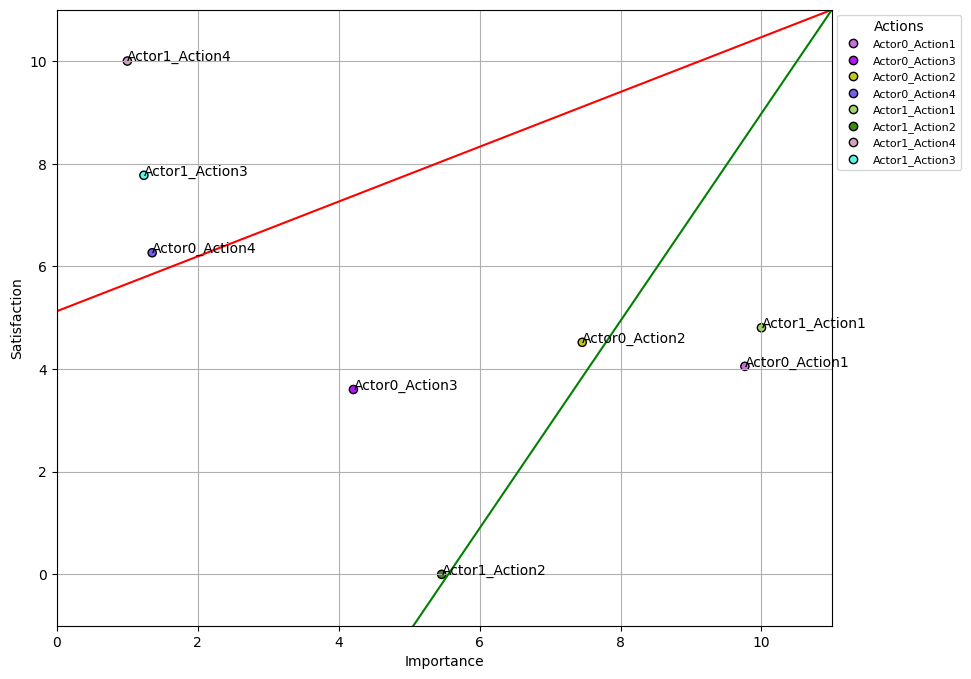

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Importance', ylabel='Satisfaction'>)

In [97]:
# 그림그리기 함수 호출
plot_opportunity_area(DCX_summary, cfg) # 데이터, 설정값